<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/25_missing_indicator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [76]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/train.csv",usecols=['Age','Fare','Survived'])
data = pd.read_csv('https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [77]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [78]:
data.head(2)

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500


In [79]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [80]:
df.head(2)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833


In [81]:
df["Age_impute"]=df["Age"]

In [82]:
df.sample(5)

,Survived,Age,Fare,Age_impute
159,0,NaN,69.5500,NaN
179,0,36.0,0.0000,36.0
684,0,60.0,39.0000,60.0
195,1,58.0,146.5208,58.0
37,0,21.0,8.0500,21.0


In [83]:
df["Age_impute"][df["Age_impute"].isnull()]=df["Age"].dropna().sample(df["Age"].isnull().sum()).values

/tmp/ipykernel_667/3119095079.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Age_impute"][df["Age_impute"].isnull()]=df["Age"].dropna().sample(df["Age"].isnull().sum()).values
/tmp/ipykernel_667/3119095079.py:1: SettingWithCopyWarni

In [84]:
df

,Survived,Age,Fare,Age_impute
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0
...,...,...,...,...
886,0,27.0,13.0000,27.0
887,1,19.0,30.0000,19.0
888,0,NaN,23.4500,24.0
889,1,26.0,30.0000,26.0


<Axes: xlabel='Age', ylabel='Density'>

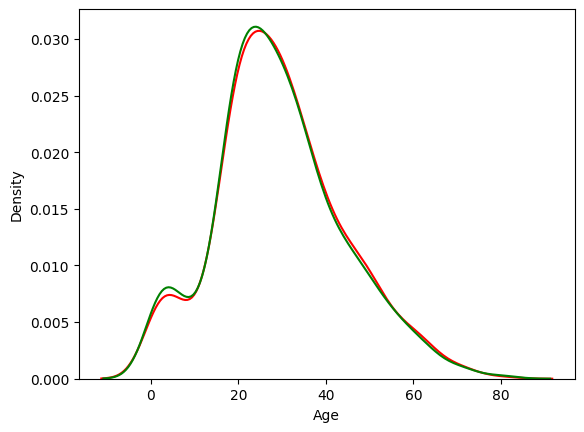

In [86]:
sns.kdeplot(df["Age"], color="red")
sns.kdeplot(df["Age_impute"], color="green")

In [88]:
print("orinal Age Varianve",df["Age"].var())
print("Inpute Age Varianve",df["Age_impute"].var())

orinal Age Varianve 211.0191247463081
Inpute Age Varianve 212.34150709895482


<Axes: >

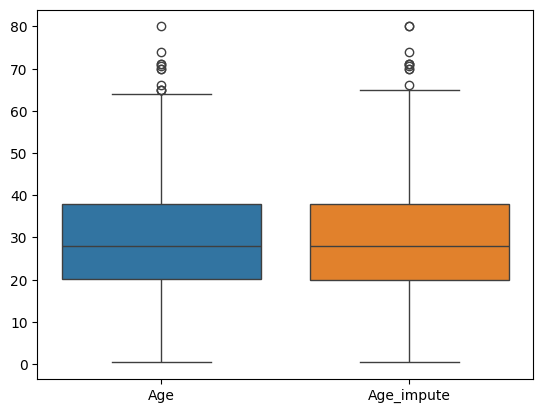

In [90]:
sns.boxplot(df[["Age","Age_impute"]])

In [93]:
#sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [94]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [95]:
data.isnull().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


In [102]:
data["FireplaceQu_impute"]=data["GarageQual"]
data["GarageQual_impute"]=data["GarageQual"]

In [110]:
data["FireplaceQu_impute"][data["FireplaceQu_impute"].isnull()]=data["GarageQual"].dropna().sample(data["GarageQual"].isnull().sum()).values
data["GarageQual_impute"][data["GarageQual_impute"].isnull()]=data["GarageQual"].dropna().sample(data["GarageQual"].isnull().sum()).values

/tmp/ipykernel_667/2059329780.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data["FireplaceQu_impute"][data["FireplaceQu_impute"].isnull()]=data["GarageQual"].dropna().sample(data["GarageQual"].isnull().sum()).values
/tmp/ipykernel_667

In [111]:
data

,FireplaceQu,GarageQual,SalePrice,FireplaceQu_impute,GarageQual_impute
0,NaN,TA,208500,TA,TA
1,TA,TA,181500,TA,TA
2,TA,TA,223500,TA,TA
3,Gd,TA,140000,TA,TA
4,TA,TA,250000,TA,TA
...,...,...,...,...,...
1455,TA,TA,175000,TA,TA
1456,TA,TA,210000,TA,TA
1457,Gd,TA,266500,TA,TA
1458,NaN,TA,142125,TA,TA


In [117]:
data["GarageQual"].isnull().sum()

np.int64(81)

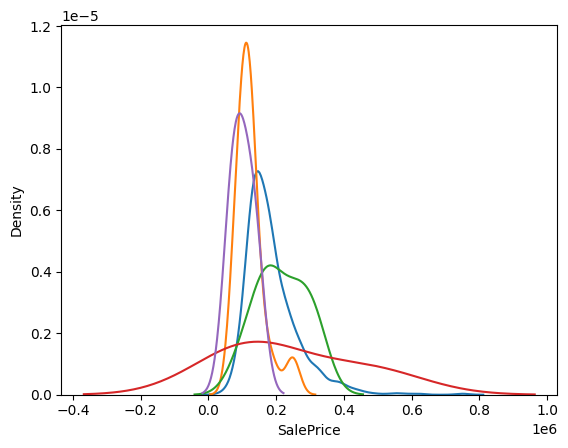

In [123]:
for cat in data["GarageQual"].dropna().unique():
  sns.kdeplot(data[data["GarageQual"]==cat]["SalePrice"])

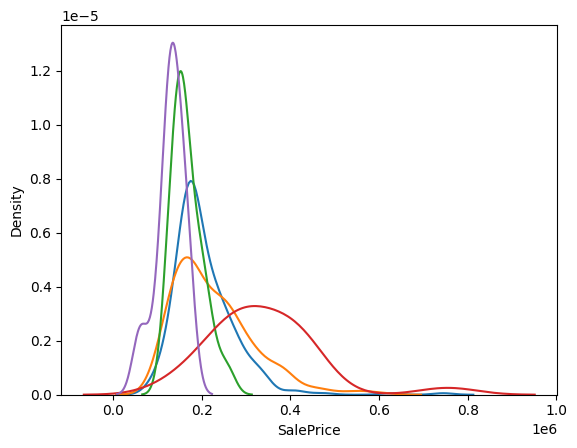

In [125]:
for cat in data["FireplaceQu"].dropna().unique():
  sns.kdeplot(data[data["FireplaceQu"]==cat]["SalePrice"])

In [148]:
temp= pd.concat([
    data["FireplaceQu"].value_counts()/len(data),
     data["FireplaceQu_impute"].value_counts()/len(data)
], axis=1)

In [149]:
temp.columns = ['original', 'imputed']

In [150]:
temp

,original,imputed
Gd,0.260274,0.009589
TA,0.214384,0.951370
Fa,0.022603,0.034932
Ex,0.016438,0.002055
Po,0.013699,0.002055
